# 🟢 Lesson 04 — Matplotlib

**Level: Beginner** · The standard plotting library — histograms, scatter plots, downhole logs, publication figures.

*Part of the companion package for [python_for_geologists](https://github.com/kevinalexandr19/python_for_geologists) by Kevin Alexander Gomez.*

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

DATA = Path("..") / "data"
assay = pd.read_csv(DATA / "assay.csv")
rocks = pd.read_csv(DATA / "rocks.csv")

## 1. Histogram — grade distribution
Ore grades are almost always right-skewed (log-normal-ish).

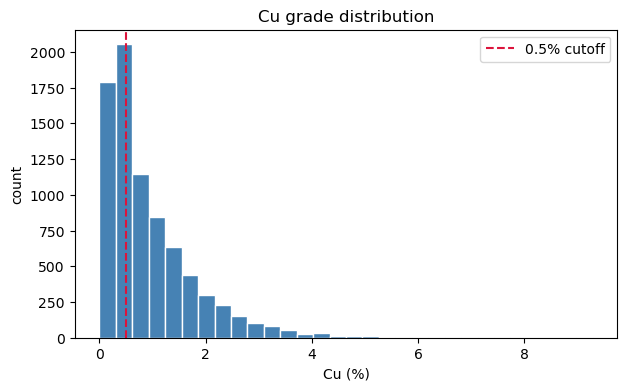

In [2]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(assay["CU_pct"].dropna(), bins=30, color="steelblue", edgecolor="white")
ax.axvline(0.5, color="crimson", ls="--", label="0.5% cutoff")
ax.set_xlabel("Cu (%)"); ax.set_ylabel("count"); ax.set_title("Cu grade distribution")
ax.legend(); plt.show()

## 2. Scatter — Harker diagram (SiO₂ vs K₂O)

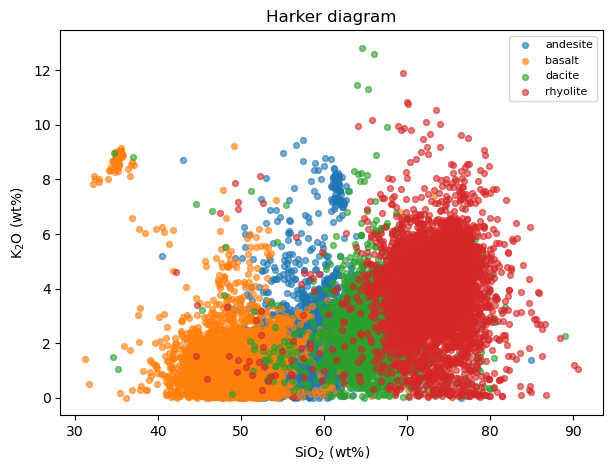

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, grp in rocks.groupby("Name"):
    ax.scatter(grp["SiO2"], grp["K2O"], s=18, alpha=0.6, label=name)
ax.set_xlabel("SiO$_2$ (wt%)"); ax.set_ylabel("K$_2$O (wt%)")
ax.set_title("Harker diagram"); ax.legend(fontsize=8)
plt.show()

## 3. Downhole log — grade vs depth for one drillhole

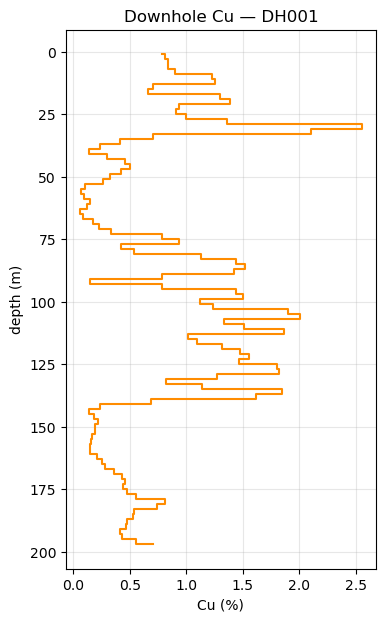

In [4]:
dh = assay[assay["ID"] == assay["ID"].iloc[0]].copy()
mid = (dh["FROM"] + dh["TO"]) / 2

fig, ax = plt.subplots(figsize=(4, 7))
ax.step(dh["CU_pct"], mid, where="mid", color="darkorange")
ax.invert_yaxis()                      # depth increases downwards!
ax.set_xlabel("Cu (%)"); ax.set_ylabel("depth (m)")
ax.set_title(f"Downhole Cu — {dh['ID'].iloc[0]}")
ax.grid(alpha=0.3); plt.show()

## 4. Subplots — a compact multi-element panel

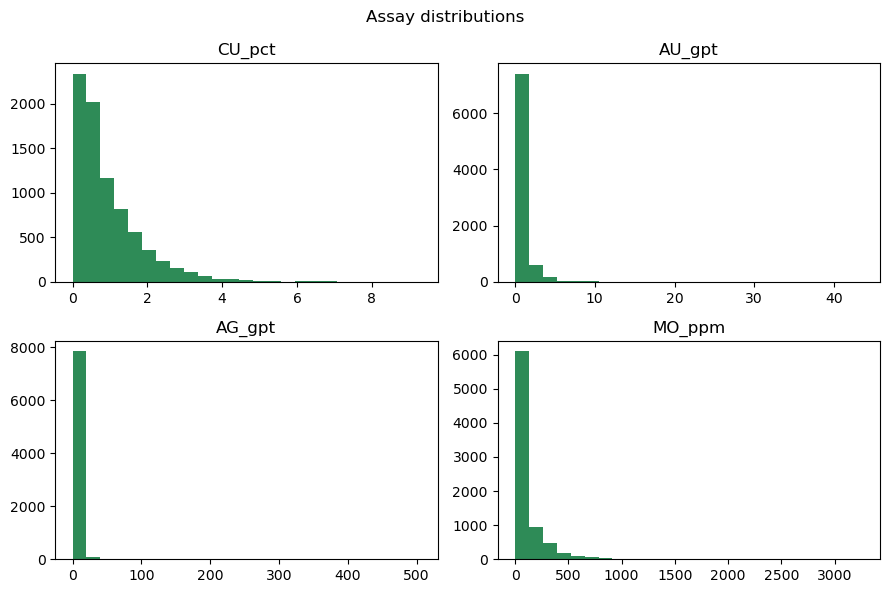

In [5]:
elements = ["CU_pct", "AU_gpt", "AG_gpt", "MO_ppm"]
fig, axes = plt.subplots(2, 2, figsize=(9, 6))
for ax, el in zip(axes.flat, elements):
    ax.hist(assay[el].dropna(), bins=25, color="seagreen")
    ax.set_title(el)
fig.suptitle("Assay distributions"); fig.tight_layout()
plt.show()

## 5. Save a publication-ready figure

In [6]:
out = Path("outputs"); out.mkdir(exist_ok=True)
fig.savefig(out / "assay_panel.png", dpi=200, bbox_inches="tight")
print("saved ->", out / "assay_panel.png")

saved -> outputs\assay_panel.png


### ✏️ Try it
1. Plot Au vs Cu as a scatter, log-scaled on both axes (`ax.set_xscale('log')`).
2. Make a downhole plot for a *different* drillhole and add a shaded ore zone with `ax.axhspan()`.

📚 Docs: https://matplotlib.org/stable/